# WasteWise – Dataset Playground

This notebook explores the TrashNet dataset for the WasteWise project.

**Dataset:** TrashNet  
**Purpose:** Initial inspection of image data for waste classification  
**Dataset access:** Public TrashNet dataset retrieved from Hugging Face  
**Retrieved:** October 5, 2026

In [15]:
import os
import sys

print("Python version:", sys.version)
print("Working directory:", os.getcwd())

Python version: 3.13.16 (main, Sep 30 2026, 18:57:20) [Clang 21.0.0 (clang-2100.3.34.2)]
Working directory: /Users/sofiapedraza/Projects/WasteWise


In [2]:
from pathlib import Path

zip_path = Path("data/dataset-resized.zip")

print("Dataset found:", zip_path.exists())

if zip_path.exists():
    print(f"File size: {zip_path.stat().st_size / 1_000_000:.2f} MB")

Dataset found: True
File size: 42.83 MB


In [3]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_file:
    file_names = zip_file.namelist()

print("Number of entries in ZIP:", len(file_names))
print("\nFirst 10 entries:")

for name in file_names[:10]:
    print(name)

Number of entries in ZIP: 2540

First 10 entries:
dataset-resized/
dataset-resized/.DS_Store
__MACOSX/
__MACOSX/dataset-resized/
__MACOSX/dataset-resized/._.DS_Store
dataset-resized/cardboard/
dataset-resized/cardboard/cardboard1.jpg
dataset-resized/cardboard/cardboard10.jpg
dataset-resized/cardboard/cardboard100.jpg
dataset-resized/cardboard/cardboard101.jpg


In [4]:
import zipfile
from pathlib import Path

data_dir = Path("data")
extract_dir = data_dir / "dataset-resized"

if not extract_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(data_dir)
    print("Dataset extracted successfully.")
else:
    print("Dataset is already extracted.")

Dataset is already extracted.


In [5]:
print("Dataset path:", extract_dir)
print("Folders:")

for folder in sorted(extract_dir.iterdir()):
    if folder.is_dir():
        print("-", folder.name)

Dataset path: data/dataset-resized
Folders:
- cardboard
- glass
- metal
- paper
- plastic
- trash


In [6]:
from collections import Counter

image_extensions = {".jpg", ".jpeg", ".png"}

class_counts = {}

for class_folder in sorted(extract_dir.iterdir()):
    if class_folder.is_dir():
        count = sum(
            1
            for file in class_folder.iterdir()
            if file.suffix.lower() in image_extensions
        )
        class_counts[class_folder.name] = count

class_counts

{'cardboard': 403,
 'glass': 501,
 'metal': 410,
 'paper': 594,
 'plastic': 482,
 'trash': 137}

In [7]:
total_images = sum(class_counts.values())

print("Total number of images:", total_images)

Total number of images: 2527


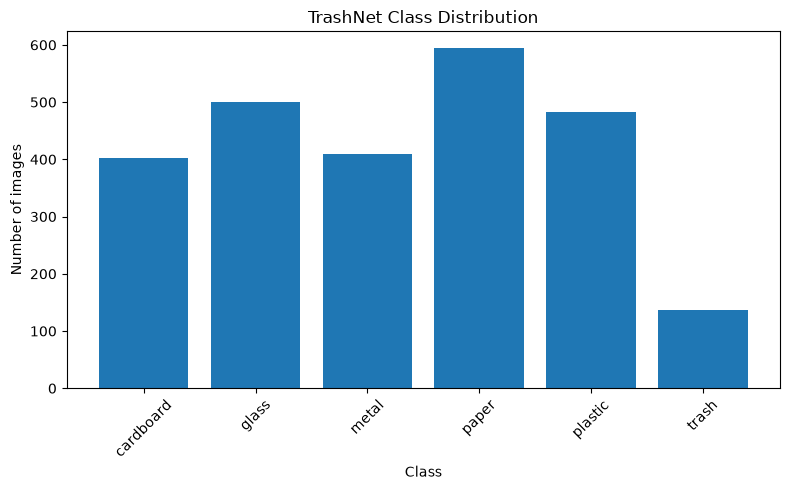

In [8]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("TrashNet Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Initial observation

The dataset is not perfectly balanced across classes. Most categories contain approximately
400–600 images, while the `trash` class contains only 137 images. This imbalance may affect
model performance, particularly for the underrepresented `trash` category.

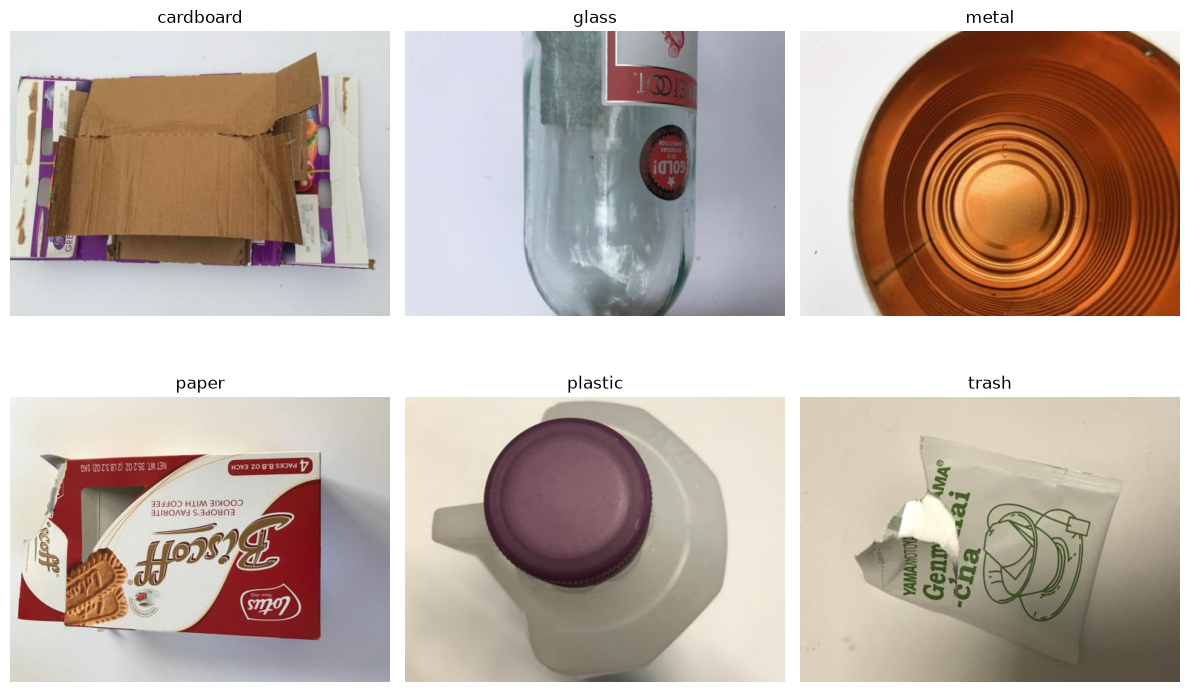

In [9]:
from PIL import Image
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, class_name in zip(axes.flatten(), sorted(class_counts.keys())):
    
    class_folder = extract_dir / class_name
    
    images = [
        file for file in class_folder.iterdir()
        if file.suffix.lower() in image_extensions
    ]
    
    sample_image = random.choice(images)
    
    image = Image.open(sample_image)
    
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Visual inspection

The images show that the TrashNet categories are broader than the categories planned for
WasteWise. For example, the `plastic` category is not limited to plastic bottles, and the
`metal` category is not limited to aluminum cans.

Therefore, TrashNet can be useful for initial experimentation, but additional filtering or
a more task-specific dataset may be needed for the final WasteWise classifier.

In [10]:
from collections import Counter
from PIL import Image

image_sizes = Counter()
image_formats = Counter()
bad_images = []

for class_folder in sorted(extract_dir.iterdir()):
    if class_folder.is_dir():
        for file in class_folder.iterdir():
            if file.suffix.lower() in image_extensions:
                try:
                    with Image.open(file) as img:
                        image_sizes[img.size] += 1
                        image_formats[img.format] += 1
                except Exception:
                    bad_images.append(file)

print("Image formats:")
print(image_formats)

print("\nMost common image sizes:")
for size, count in image_sizes.most_common(10):
    print(size, ":", count)

print("\nUnreadable images:", len(bad_images))

Image formats:
Counter({'JPEG': 2527})

Most common image sizes:
(512, 384) : 2527

Unreadable images: 0


In [11]:
print("Number of different image sizes:", len(image_sizes))

Number of different image sizes: 1


### Image consistency

All 2,527 images were successfully opened with no unreadable files detected.

The dataset is highly consistent in its image representation:

- All images are stored in JPEG format.
- All images have the same resolution of 512 × 384 pixels.
- Only one image size is present across the entire dataset.

This consistency simplifies preprocessing because the images do not require resizing solely to standardize their dimensions.

In [12]:
image_modes = Counter()

for class_folder in sorted(extract_dir.iterdir()):
    if class_folder.is_dir():
        for file in class_folder.iterdir():
            if file.suffix.lower() in image_extensions:
                with Image.open(file) as img:
                    image_modes[img.mode] += 1

print("Image modes:")
print(image_modes)

Image modes:
Counter({'RGB': 2527})


All images are represented as RGB images, providing a consistent three-channel input format for future computer vision experiments.

## Dataset source and license

This project uses the **TrashNet** dataset created by Gary Thung and Mindy Yang
for a Stanford CS229 project.

- **Dataset:** TrashNet
- **Authors:** Gary Thung and Mindy Yang
- **Classes:** cardboard, glass, metal, paper, plastic, trash
- **Number of images:** 2,527
- **Image size:** 512 × 384 pixels
- **License:** MIT, as indicated in the author's Hugging Face dataset repository
- **Retrieved:** October 5, 2026

Original repository:
https://github.com/garythung/trashnet

Dataset download:
https://huggingface.co/datasets/garythung/trashnet

### Citation

Thung, G. and Yang, M. *Classification of Trash for Recyclability Status*.
Stanford CS229 Project, 2016.

The original TrashNet repository requests that users cite the repository when
using the dataset.

In [13]:
from pathlib import Path
from urllib.request import urlretrieve

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "dataset-resized.zip"

dataset_url = (
    "https://huggingface.co/datasets/garythung/trashnet/"
    "resolve/main/dataset-resized.zip"
)

if zip_path.exists():
    print("Dataset already available locally.")
else:
    print("Dataset not found. Downloading TrashNet...")
    urlretrieve(dataset_url, zip_path)
    print("Download complete.")

print("Dataset path:", zip_path)

Dataset already available locally.
Dataset path: data/dataset-resized.zip


In [14]:
import zipfile

extract_dir = data_dir / "dataset-resized"

if extract_dir.exists():
    print("Dataset already extracted.")
else:
    with zipfile.ZipFile(zip_path, "r") as zip_file:
        zip_file.extractall(data_dir)
    print("Dataset extracted successfully.")

Dataset already extracted.
